# Khảo Sát Không Gian Đặc Trưng (2D $\rightarrow$ 5D) & Tối Ưu Siêu Tham Số K-Means

Mục tiêu của notebook này là xây dựng, khảo sát và tối ưu thuật toán **K-Means Clustering tự viết từ đầu (from scratch)** qua các nội dung:
1. **Khảo sát 5 không gian đặc trưng** (2D, 3D Nhân khẩu, 3D Tỷ lệ, 4D, 5D) với số cụm $K \in [2, 9]$.
2. **Vẽ đồ thị cùi chỏ (Elbow curves)** cho cả 5 không gian để tìm điểm cùi chỏ tối ưu.
3. **Tối ưu hóa siêu tham số (Grid Search)** trên 3 không gian trọng tâm (2D, 3D Tỷ lệ, 5D) quét qua $K \in [2, 9]$, `max_iters` $\in [100, 500]$ và phương pháp khởi tạo (`random` vs `kmeans++`).
4. **Trực quan hóa so sánh 3x2** (Trước và sau tối ưu) của 3 không gian này chiếu lên mặt phẳng Thu nhập - Chi tiêu.

## Bước 1. Chuẩn Bị Dữ Liệu

Đọc dữ liệu tiền xử lý đã chuẩn hóa.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import pickle
import os
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# Đọc dữ liệu tiền xử lý
df = pd.read_csv('../data/ready_train/shopping_mall_preprocessed.csv')
print(f"Kích thước dữ liệu: {df.shape[0]:,} hàng, {df.shape[1]} cột")
print("Các cột đặc trưng: ", df.columns.tolist())
df.head()

Kích thước dữ liệu: 15,079 hàng, 6 cột
Các cột đặc trưng:  ['Customer ID', 'Gender_encoded', 'Age_scaled', 'Annual Income_scaled', 'Spending Score_scaled', 'Spending_to_Income_Ratio_scaled']


,Customer ID,Gender_encoded,Age_scaled,Annual Income_scaled,Spending Score_scaled,Spending_to_Income_Ratio_scaled
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,1,-1.145516,0.798813,1.337059,-0.095878
1,1770b26f-493f-46b6-837f-4237fb5a314e,0,0.180335,1.442076,1.545929,-0.208511
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,0,0.369742,-0.743208,0.884507,0.638431
3,9795712a-ad19-47bf-8886-4f997d6046e3,1,-1.476979,-1.038953,0.223086,0.571730
4,64139426-2226-4cd6-bf09-91bce4b4db5e,1,-1.429627,0.842317,0.884507,-0.237274


## Bước 2. Định Nghĩa Thuật Toán K-Means Từ Đầu (From Scratch)

Hỗ trợ khởi tạo nâng cao (`kmeans++`) và tùy chọn đo khoảng cách (`euclidean` vs `manhattan`).

In [2]:
class KMeansScratch:
    def __init__(self, n_clusters=5, max_iters=100, init='random', metric='euclidean', random_state=42):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.init = init
        self.metric = metric
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None
        self.inertia_ = None
        self.n_iter_ = 0
        
    def fit(self, X):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape
        
        # 1. Khởi tạo tâm cụm
        if self.init == 'random':
            random_idx = np.random.choice(n_samples, self.n_clusters, replace=False)
            self.centroids = X[random_idx].copy()
        elif self.init == 'kmeans++':
            centroids = [X[np.random.choice(n_samples)]]
            for _ in range(1, self.n_clusters):
                dists_min = np.min([np.sum((X - c)**2, axis=1) for c in centroids], axis=0)
                probs = dists_min / dists_min.sum()
                next_c_idx = np.random.choice(n_samples, p=probs)
                centroids.append(X[next_c_idx])
            self.centroids = np.array(centroids)
            
        # Tiền tính X_squared_norm cho Euclidean
        X_squared = np.sum(X**2, axis=1, keepdims=True)
        
        # 2. Vòng lặp tối ưu
        for i in range(self.max_iters):
            self.n_iter_ = i + 1
            if self.metric == 'euclidean':
                # dists = ||X - centroids||^2 = ||X||^2 - 2 * X.centroids^T + ||centroids||^2
                distances = X_squared - 2 * np.dot(X, self.centroids.T) + np.sum(self.centroids**2, axis=1)
            elif self.metric == 'manhattan':
                distances = np.sum(np.abs(X[:, np.newaxis] - self.centroids), axis=2)
                
            labels = np.argmin(distances, axis=1)
            
            new_centroids = []
            for k in range(self.n_clusters):
                cluster_pts = X[labels == k]
                if len(cluster_pts) > 0:
                    if self.metric == 'manhattan':
                        new_centroids.append(np.median(cluster_pts, axis=0))
                    else:
                        new_centroids.append(cluster_pts.mean(axis=0))    
                else:
                    new_centroids.append(self.centroids[k])
            new_centroids = np.array(new_centroids)
            
            if np.allclose(self.centroids, new_centroids):
                break
            self.centroids = new_centroids
            
        self.labels_ = labels
        self.inertia_ = np.sum((X - self.centroids[self.labels_]) ** 2)
        return self

## Bước 3. Khảo Sát Các Không Gian Đặc Trưng (2D $\rightarrow$ 5D)

Chạy thử nghiệm K-Means trên các không gian đầu vào từ 2D trở lên với số cụm $K \in [2, 9]$.

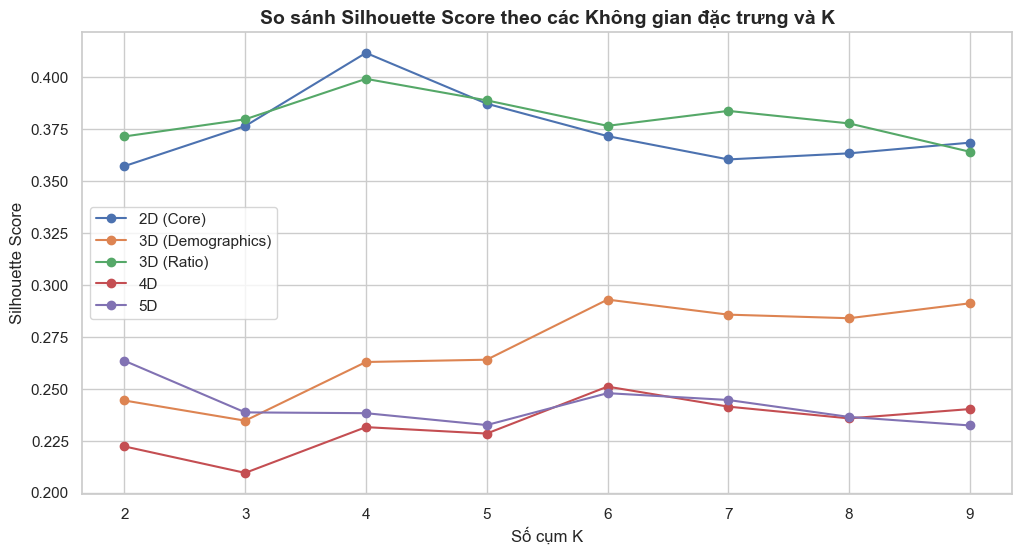

,Space,K,Silhouette,Calinski-Harabasz,Davies-Bouldin,Inertia
0,2D (Core),2,0.357152,8972.246552,1.193219,18906.711486
1,2D (Core),3,0.376450,11410.653514,0.871145,11997.211508
2,2D (Core),4,0.411681,15049.279310,0.767774,7549.160180
3,2D (Core),5,0.387221,14038.929637,0.887316,6382.191328
4,2D (Core),6,0.371604,13877.971238,0.836544,5381.910517
5,2D (Core),7,0.360385,13855.915270,0.855286,4628.377820
6,2D (Core),8,0.363313,14545.695646,0.797209,3888.338070
7,2D (Core),9,0.368455,15166.471560,0.770890,3331.929283
8,3D (Demographics),2,0.244308,4991.638181,1.655769,33985.278067
9,3D (Demographics),3,0.234588,5075.351691,1.332584,27034.567366


In [3]:
spaces = {
    '2D (Core)': ['Annual Income_scaled', 'Spending Score_scaled'],
    '3D (Demographics)': ['Age_scaled', 'Annual Income_scaled', 'Spending Score_scaled'],
    '3D (Ratio)': ['Annual Income_scaled', 'Spending Score_scaled', 'Spending_to_Income_Ratio_scaled'],
    '4D': ['Gender_encoded', 'Age_scaled', 'Annual Income_scaled', 'Spending Score_scaled'],
    '5D': ['Gender_encoded', 'Age_scaled', 'Annual Income_scaled', 'Spending Score_scaled', 'Spending_to_Income_Ratio_scaled']
}

exploration_results = []
k_range = range(2, 10) # K từ 2 đến 9

for space_name, cols in spaces.items():
    X = df[cols].values
    for k in k_range:
        km = KMeansScratch(n_clusters=k, random_state=42)
        km.fit(X)
        sil = silhouette_score(X, km.labels_, sample_size=3000, random_state=42)
        ch = calinski_harabasz_score(X, km.labels_)
        db = davies_bouldin_score(X, km.labels_)
        exploration_results.append({
            'Space': space_name,
            'K': k,
            'Silhouette': sil,
            'Calinski-Harabasz': ch,
            'Davies-Bouldin': db,
            'Inertia': km.inertia_
        })

df_exploration = pd.DataFrame(exploration_results)

# Vẽ biểu đồ đường so sánh Silhouette Score giữa các không gian
plt.figure(figsize=(12, 6))
for space_name in spaces.keys():
    df_sub = df_exploration[df_exploration['Space'] == space_name]
    plt.plot(df_sub['K'], df_sub['Silhouette'], marker='o', label=space_name)
plt.title('So sánh Silhouette Score theo các Không gian đặc trưng và K', fontsize=14, fontweight='bold')
plt.xlabel('Số cụm K')
plt.ylabel('Silhouette Score')
plt.xticks(list(k_range))
plt.legend()
plt.show()

df_exploration.head(16)

## Bước 4. Vẽ Đồ Thị Cùi Chỏ (Elbow Curves) Cho 5 Không Gian

Tìm và đánh dấu điểm cùi chỏ tự động bằng phương pháp khoảng cách vector Satopaa.

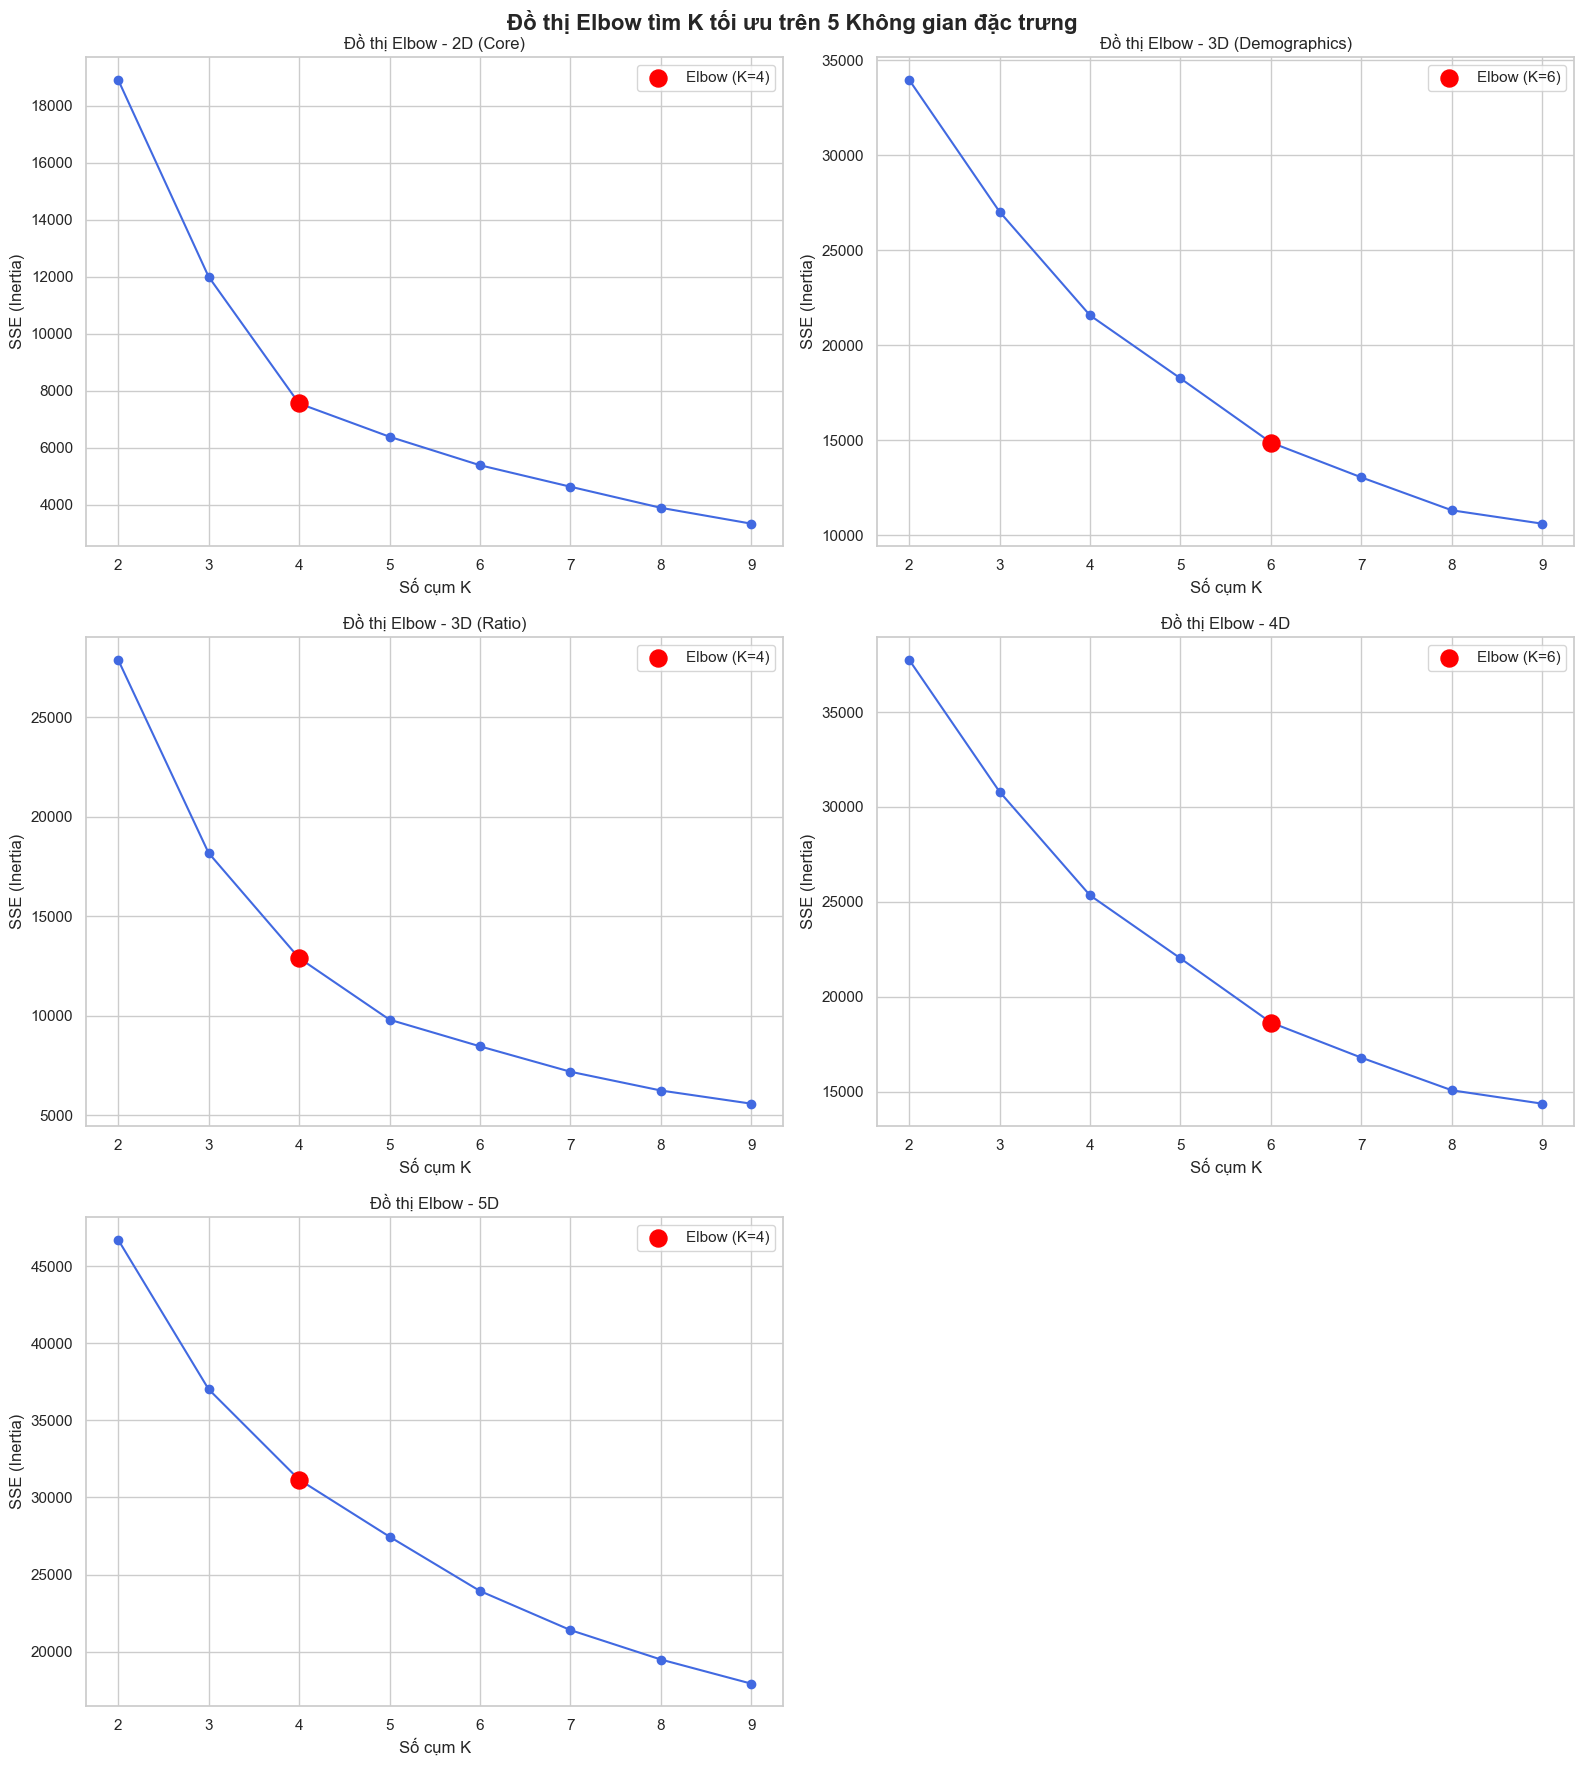

Tập hợp gợi ý K tối ưu tự động:  {'2D (Core)': 4, '3D (Demographics)': 6, '3D (Ratio)': 4, '4D': 6, '5D': 4}


In [4]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

optimal_k_values = {}

for idx, (space_name, cols) in enumerate(spaces.items()):
    df_sub = df_exploration[df_exploration['Space'] == space_name].sort_values('K')
    sse_values = df_sub['Inertia'].values
    k_vals = df_sub['K'].values
    
    # Satopaa vector method
    coords = np.vstack((k_vals, sse_values)).T
    line_vec = coords[-1] - coords[0]
    line_vec_norm = line_vec / np.linalg.norm(line_vec)
    vec_to_start = coords - coords[0]
    proj = np.dot(vec_to_start, line_vec_norm)
    perp = vec_to_start - proj[:, np.newaxis] * line_vec_norm
    elbow_idx = np.argmax(np.linalg.norm(perp, axis=1))
    k_elbow = int(k_vals[elbow_idx])
    optimal_k_values[space_name] = k_elbow
    elbow_sse = sse_values[elbow_idx]
    
    # Vẽ Elbow curve
    ax = axes[idx]
    ax.plot(k_vals, sse_values, marker='o', color='royalblue')
    ax.scatter(k_elbow, elbow_sse, color='red', s=150, zorder=5, label=f'Elbow (K={k_elbow})')
    ax.set_title(f'Đồ thị Elbow - {space_name}')
    ax.set_xlabel('Số cụm K')
    ax.set_ylabel('SSE (Inertia)')
    ax.set_xticks(list(k_range))
    ax.legend()

# Ẩn trục thừa thứ 6
axes[5].set_visible(False)

plt.suptitle('Đồ thị Elbow tìm K tối ưu trên 5 Không gian đặc trưng', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print("Tập hợp gợi ý K tối ưu tự động: ", optimal_k_values)

## Bước 5. Tối Ưu Hóa Siêu Tham Số (Grid Search Tuning)

Thực thi quét tham số trên 3 không gian trọng tâm:
1. **2D (Core)**
2. **3D (Ratio)**
3. **5D (Full)**

In [5]:
target_spaces = ['2D (Core)', '3D (Ratio)', '5D']
tuning_results = {}

for space_name in target_spaces:
    print(f"\n=== GRID TUNING CHO KHÔNG GIAN: {space_name} ===")
    X = df[spaces[space_name]].values
    
    best_sil = -1
    best_params = {}
    
    for k in range(2, 10): # K từ 2 đến 9
        for max_iter in [100, 500]:
            for init_method in ['random', 'kmeans++']:
                t0 = time.time()
                km = KMeansScratch(n_clusters=k, max_iters=max_iter, init=init_method, random_state=42)
                km.fit(X)
                duration = time.time() - t0
                
                sil = silhouette_score(X, km.labels_, sample_size=3000, random_state=42)
                if sil > best_sil:
                    best_sil = sil
                    best_params = {
                        'K': k,
                        'max_iter': max_iter,
                        'init': init_method,
                        'duration': duration,
                        'model': km
                    }
    
    tuning_results[space_name] = best_params
    print(f"-> Kết quả tốt nhất: K={best_params['K']}, max_iter={best_params['max_iter']}, init={best_params['init']} | Silhouette: {best_sil:.4f}")


=== GRID TUNING CHO KHÔNG GIAN: 2D (Core) ===


-> Kết quả tốt nhất: K=4, max_iter=100, init=random | Silhouette: 0.4117

=== GRID TUNING CHO KHÔNG GIAN: 3D (Ratio) ===


-> Kết quả tốt nhất: K=4, max_iter=100, init=random | Silhouette: 0.3992

=== GRID TUNING CHO KHÔNG GIAN: 5D ===


-> Kết quả tốt nhất: K=2, max_iter=100, init=random | Silhouette: 0.2634


## Bước 6. Trực Quan Hóa Ma Trận 3x2 (Trước và Sau Tối Ưu)

Xem xét sự biến chuyển ranh giới phân cụm của 3 không gian trọng tâm.

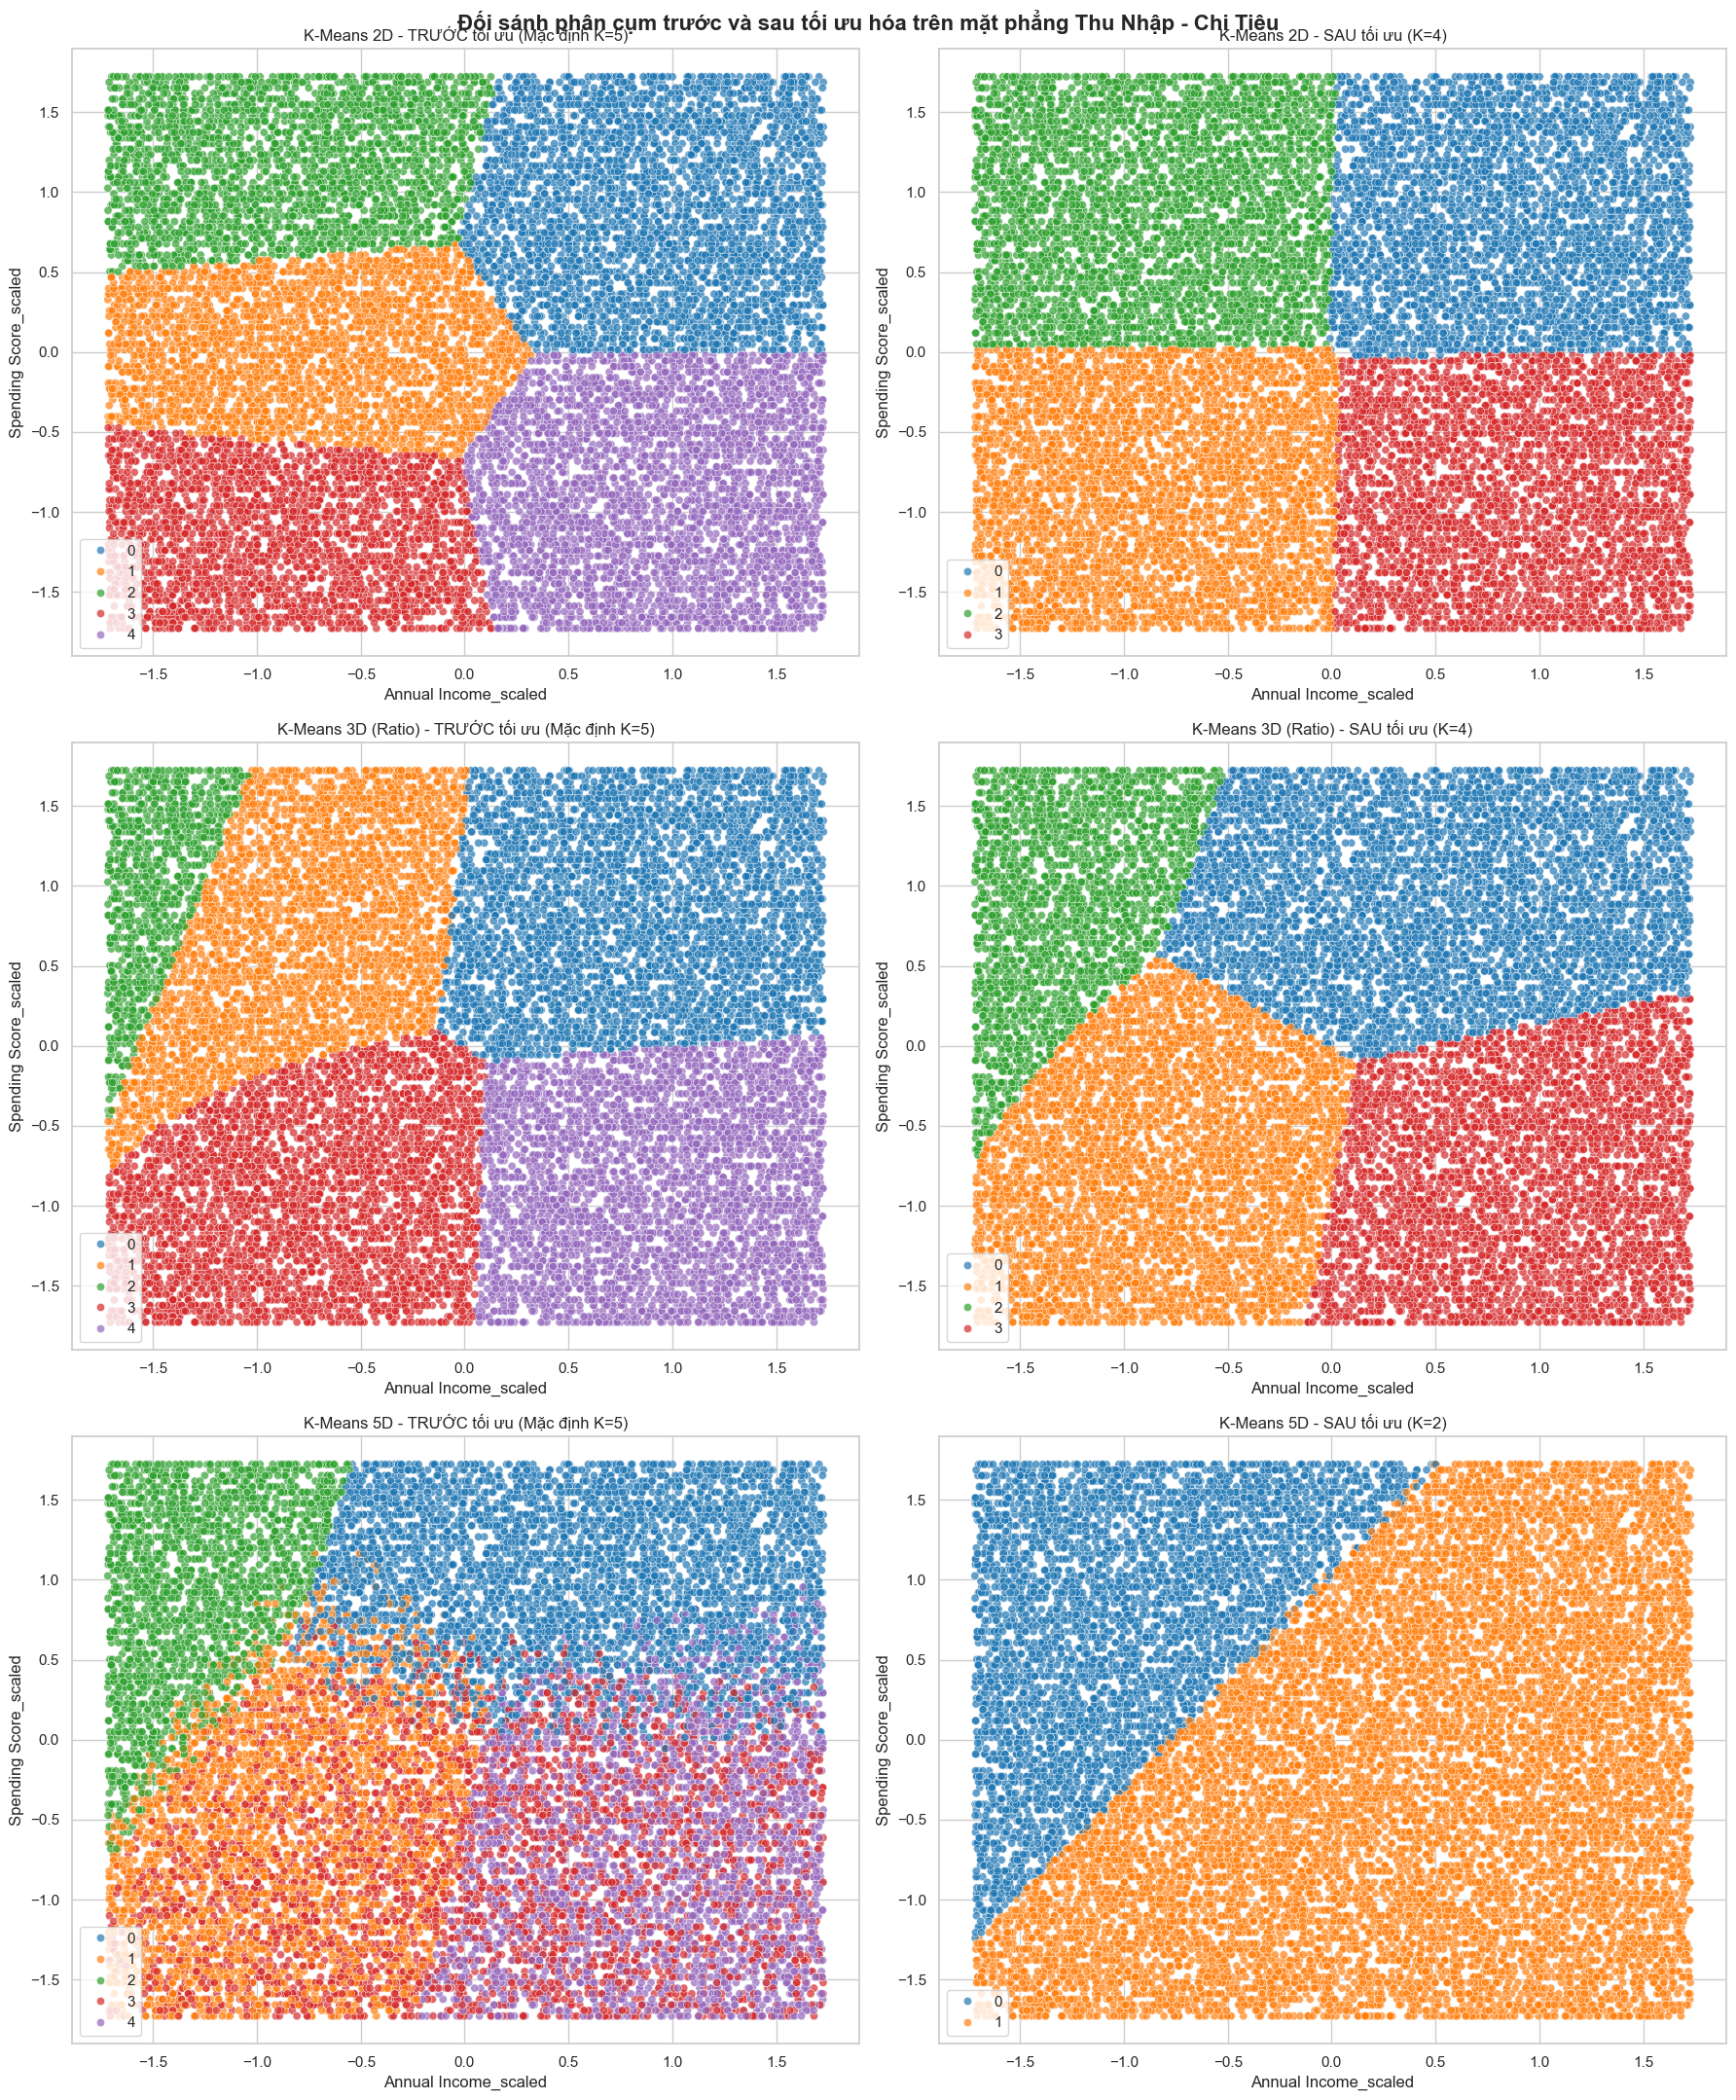

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(18, 22))

# --- HÀNG 1: KHÔNG GIAN 2D ---
X_2d = df[spaces['2D (Core)']].values
# Trước tối ưu (K=5, random, 100)
km_2d_bef = KMeansScratch(n_clusters=5, max_iters=100, init='random', random_state=42).fit(X_2d)
sns.scatterplot(data=df, x='Annual Income_scaled', y='Spending Score_scaled', hue=km_2d_bef.labels_, palette='tab10', alpha=0.7, ax=axes[0, 0])
axes[0, 0].set_title('K-Means 2D - TRƯỚC tối ưu (Mặc định K=5)')

# Sau tối ưu
km_2d_aft = tuning_results['2D (Core)']['model']
sns.scatterplot(data=df, x='Annual Income_scaled', y='Spending Score_scaled', hue=km_2d_aft.labels_, palette='tab10', alpha=0.7, ax=axes[0, 1])
axes[0, 1].set_title(f'K-Means 2D - SAU tối ưu (K={tuning_results["2D (Core)"]["K"]})')

# --- HÀNG 2: KHÔNG GIAN 3D (Ratio) ---
X_3d_ratio = df[spaces['3D (Ratio)']].values
# Trước tối ưu (K=5, random, 100)
km_3d_bef = KMeansScratch(n_clusters=5, max_iters=100, init='random', random_state=42).fit(X_3d_ratio)
sns.scatterplot(data=df, x='Annual Income_scaled', y='Spending Score_scaled', hue=km_3d_bef.labels_, palette='tab10', alpha=0.7, ax=axes[1, 0])
axes[1, 0].set_title('K-Means 3D (Ratio) - TRƯỚC tối ưu (Mặc định K=5)')

# Sau tối ưu
km_3d_aft = tuning_results['3D (Ratio)']['model']
sns.scatterplot(data=df, x='Annual Income_scaled', y='Spending Score_scaled', hue=km_3d_aft.labels_, palette='tab10', alpha=0.7, ax=axes[1, 1])
axes[1, 1].set_title(f'K-Means 3D (Ratio) - SAU tối ưu (K={tuning_results["3D (Ratio)"]["K"]})')

# --- HÀNG 3: KHÔNG GIAN 5D ---
X_5d = df[spaces['5D']].values
# Trước tối ưu (K=5, random, 100)
km_5d_bef = KMeansScratch(n_clusters=5, max_iters=100, init='random', random_state=42).fit(X_5d)
sns.scatterplot(data=df, x='Annual Income_scaled', y='Spending Score_scaled', hue=km_5d_bef.labels_, palette='tab10', alpha=0.7, ax=axes[2, 0])
axes[2, 0].set_title('K-Means 5D - TRƯỚC tối ưu (Mặc định K=5)')

# Sau tối ưu
km_5d_aft = tuning_results['5D']['model']
sns.scatterplot(data=df, x='Annual Income_scaled', y='Spending Score_scaled', hue=km_5d_aft.labels_, palette='tab10', alpha=0.7, ax=axes[2, 1])
axes[2, 1].set_title(f'K-Means 5D - SAU tối ưu (K={tuning_results["5D"]["K"]})')

plt.suptitle('Đối sánh phân cụm trước và sau tối ưu hóa trên mặt phẳng Thu Nhập - Chi Tiêu', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Bước 7. Bảng So Sánh Hiệu Năng Tổng Hợp

So sánh các chỉ số chất lượng chính.

In [7]:
# Tính toán chỉ số cho các cấu hình trước tối ưu
sil_2d_bef = silhouette_score(X_2d, km_2d_bef.labels_, sample_size=3000, random_state=42)
ch_2d_bef = calinski_harabasz_score(X_2d, km_2d_bef.labels_)
db_2d_bef = davies_bouldin_score(X_2d, km_2d_bef.labels_)

sil_3d_bef = silhouette_score(X_3d_ratio, km_3d_bef.labels_, sample_size=3000, random_state=42)
ch_3d_bef = calinski_harabasz_score(X_3d_ratio, km_3d_bef.labels_)
db_3d_bef = davies_bouldin_score(X_3d_ratio, km_3d_bef.labels_)

sil_5d_bef = silhouette_score(X_5d, km_5d_bef.labels_, sample_size=3000, random_state=42)
ch_5d_bef = calinski_harabasz_score(X_5d, km_5d_bef.labels_)
db_5d_bef = davies_bouldin_score(X_5d, km_5d_bef.labels_)

# Điểm sau tối ưu
sil_2d_aft = silhouette_score(X_2d, km_2d_aft.labels_, sample_size=3000, random_state=42)
ch_2d_aft = calinski_harabasz_score(X_2d, km_2d_aft.labels_)
db_2d_aft = davies_bouldin_score(X_2d, km_2d_aft.labels_)

sil_3d_aft = silhouette_score(X_3d_ratio, km_3d_aft.labels_, sample_size=3000, random_state=42)
ch_3d_aft = calinski_harabasz_score(X_3d_ratio, km_3d_aft.labels_)
db_3d_aft = davies_bouldin_score(X_3d_ratio, km_3d_aft.labels_)

sil_5d_aft = silhouette_score(X_5d, km_5d_aft.labels_, sample_size=3000, random_state=42)
ch_5d_aft = calinski_harabasz_score(X_5d, km_5d_aft.labels_)
db_5d_aft = davies_bouldin_score(X_5d, km_5d_aft.labels_)

comparison_matrix = [
    {
        'Mô hình': 'K-Means 2D (Trước tối ưu)',
        'Cấu hình': 'K=5, random, max_iter=100',
        'Silhouette': f'{sil_2d_bef:.4f}',
        'Calinski-Harabasz': f'{ch_2d_bef:.2f}',
        'Davies-Bouldin': f'{db_2d_bef:.4f}'
    },
    {
        'Mô hình': 'K-Means 2D (Sau tối ưu)',
        'Cấu hình': f'K={tuning_results["2D (Core)"]["K"]}, {tuning_results["2D (Core)"]["init"]}, max_iter={tuning_results["2D (Core)"]["max_iter"]}',
        'Silhouette': f'{sil_2d_aft:.4f}',
        'Calinski-Harabasz': f'{ch_2d_aft:.2f}',
        'Davies-Bouldin': f'{db_2d_aft:.4f}'
    },
    {
        'Mô hình': 'K-Means 3D Ratio (Trước tối ưu)',
        'Cấu hình': 'K=5, random, max_iter=100',
        'Silhouette': f'{sil_3d_bef:.4f}',
        'Calinski-Harabasz': f'{ch_3d_bef:.2f}',
        'Davies-Bouldin': f'{db_3d_bef:.4f}'
    },
    {
        'Mô hình': 'K-Means 3D Ratio (Sau tối ưu)',
        'Cấu hình': f'K={tuning_results["3D (Ratio)"]["K"]}, {tuning_results["3D (Ratio)"]["init"]}, max_iter={tuning_results["3D (Ratio)"]["max_iter"]}',
        'Silhouette': f'{sil_3d_aft:.4f}',
        'Calinski-Harabasz': f'{ch_3d_aft:.2f}',
        'Davies-Bouldin': f'{db_3d_aft:.4f}'
    },
    {
        'Mô hình': 'K-Means 5D (Trước tối ưu)',
        'Cấu hình': 'K=5, random, max_iter=100',
        'Silhouette': f'{sil_5d_bef:.4f}',
        'Calinski-Harabasz': f'{ch_5d_bef:.2f}',
        'Davies-Bouldin': f'{db_5d_bef:.4f}'
    },
    {
        'Mô hình': 'K-Means 5D (Sau tối ưu)',
        'Cấu hình': f'K={tuning_results["5D"]["K"]}, {tuning_results["5D"]["init"]}, max_iter={tuning_results["5D"]["max_iter"]}',
        'Silhouette': f'{sil_5d_aft:.4f}',
        'Calinski-Harabasz': f'{ch_5d_aft:.2f}',
        'Davies-Bouldin': f'{db_5d_aft:.4f}'
    }
]

df_comparison = pd.DataFrame(comparison_matrix)
df_comparison

,Mô hình,Cấu hình,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,K-Means 2D (Trước tối ưu),"K=5, random, max_iter=100",0.3872,14038.93,0.8873
1,K-Means 2D (Sau tối ưu),"K=4, random, max_iter=100",0.4117,15049.28,0.7678
2,K-Means 3D Ratio (Trước tối ưu),"K=5, random, max_iter=100",0.3888,13609.46,0.8044
3,K-Means 3D Ratio (Sau tối ưu),"K=4, random, max_iter=100",0.3992,12586.34,0.8072
4,K-Means 5D (Trước tối ưu),"K=5, random, max_iter=100",0.2325,5027.27,1.1839
5,K-Means 5D (Sau tối ưu),"K=2, random, max_iter=100",0.2634,5599.94,1.4104


## Bước 8. Lưu Mô Hình 2D K-Means Phục Vụ Deploy App

In [8]:
# === LƯU TÂM CỤM VÀ MÔ HÌNH ===
np.save('kmeans_centroids.npy', km_2d_aft.centroids)
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(km_2d_aft, f)

print("Đã lưu mô hình K-Means 2D tối ưu phục vụ deploy thành công!")

Đã lưu mô hình K-Means 2D tối ưu phục vụ deploy thành công!
